# Magpurify Precision, Recall, and F1-score

This notebook evaluates Magpurify's cleaned bins against the available ground truth.

- A contig retained in `cleaned/<bin>.fasta` is treated as Magpurify predicting that the initial binning result was correct.
- A contig from `initial_contig_bins.csv` that is absent from its cleaned bin is treated as Magpurify predicting that the initial binning result was incorrect.
- Ground-truth correctness is defined by each initial bin's majority ground-truth species. A contig is actually correct when its ground-truth species matches that majority species.


In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


In [2]:
def find_project_root(start=None) -> Path:
    """Find the repository root from either the notebook directory or project root."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "tests" / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find tests/data from the current working directory")


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "tests" / "data"
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

DATA_ROOT


PosixPath('/Users/vijinimallawaarachchi/Documents/github/BinFailGraph/tests/data')

In [3]:
def read_two_column_csv(path: Path) -> dict[str, str]:
    values = {}
    with path.open(newline="") as handle:
        for row in csv.reader(handle):
            if len(row) >= 2 and row[0].strip():
                values[row[0].strip()] = row[1].strip()
    return values


def read_fasta_ids(path: Path) -> set[str]:
    ids = set()
    with path.open() as handle:
        for line in handle:
            if line.startswith(">"):
                ids.add(line[1:].split()[0])
    return ids


def precision_recall_f1(tp: int, fp: int, fn: int) -> tuple[float, float, float]:
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1


def evaluate_dataset(dataset: Path) -> dict[str, object]:
    cleaned_dir = dataset / "cleaned"
    if not cleaned_dir.exists():
        return {"dataset": dataset.name, "status": "missing cleaned/"}

    initial_bins = read_two_column_csv(dataset / "initial_contig_bins.csv")
    ground_truth = read_two_column_csv(dataset / "ground_truth.csv")

    species_by_bin = defaultdict(Counter)
    missing_ground_truth = []
    for contig, bin_label in initial_bins.items():
        species = ground_truth.get(contig)
        if species is None:
            missing_ground_truth.append(contig)
        else:
            species_by_bin[bin_label][species] += 1

    majority_species_by_bin = {
        bin_label: species_counts.most_common(1)[0][0]
        for bin_label, species_counts in species_by_bin.items()
        if species_counts
    }

    retained_by_bin = defaultdict(set)
    for fasta_path in cleaned_dir.glob("*.fasta"):
        retained_by_bin[fasta_path.stem].update(read_fasta_ids(fasta_path))

    tp = fp = fn = tn = 0
    retained = removed = actual_correct = actual_incorrect = 0

    for contig, bin_label in initial_bins.items():
        species = ground_truth.get(contig)
        majority_species = majority_species_by_bin.get(bin_label)
        if species is None or majority_species is None:
            continue

        is_actually_correct = species == majority_species
        is_predicted_correct = contig in retained_by_bin.get(bin_label, set())

        retained += int(is_predicted_correct)
        removed += int(not is_predicted_correct)
        actual_correct += int(is_actually_correct)
        actual_incorrect += int(not is_actually_correct)

        if is_predicted_correct and is_actually_correct:
            tp += 1
        elif is_predicted_correct and not is_actually_correct:
            fp += 1
        elif not is_predicted_correct and is_actually_correct:
            fn += 1
        else:
            tn += 1

    precision, recall, f1 = precision_recall_f1(tp, fp, fn)
    return {
        "dataset": dataset.name,
        "status": "ok",
        "initial_contigs": len(initial_bins),
        "scored_contigs": tp + fp + fn + tn,
        "bins": len(majority_species_by_bin),
        "retained": retained,
        "removed": removed,
        "actual_correct": actual_correct,
        "actual_incorrect": actual_incorrect,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "missing_ground_truth": len(missing_ground_truth),
    }


In [4]:
results = [
    evaluate_dataset(dataset)
    for dataset in sorted(DATA_ROOT.iterdir())
    if dataset.is_dir() and (dataset / "initial_contig_bins.csv").exists()
]

results


[{'dataset': 'Sim-100G',
  'status': 'ok',
  'initial_contigs': 5723,
  'scored_contigs': 3976,
  'bins': 95,
  'retained': 3650,
  'removed': 326,
  'actual_correct': 2827,
  'actual_incorrect': 1149,
  'tp': 2729,
  'fp': 921,
  'fn': 98,
  'tn': 228,
  'precision': 0.7476712328767123,
  'recall': 0.9653342766183233,
  'f1_score': 0.8426740775050177,
  'missing_ground_truth': 1747},
 {'dataset': 'Sim-10G',
  'status': 'ok',
  'initial_contigs': 341,
  'scored_contigs': 331,
  'bins': 10,
  'retained': 320,
  'removed': 11,
  'actual_correct': 307,
  'actual_incorrect': 24,
  'tp': 302,
  'fp': 18,
  'fn': 5,
  'tn': 6,
  'precision': 0.94375,
  'recall': 0.9837133550488599,
  'f1_score': 0.9633173843700158,
  'missing_ground_truth': 10},
 {'dataset': 'Sim-20G',
  'status': 'ok',
  'initial_contigs': 610,
  'scored_contigs': 597,
  'bins': 21,
  'retained': 585,
  'removed': 12,
  'actual_correct': 539,
  'actual_incorrect': 58,
  'tp': 534,
  'fp': 51,
  'fn': 5,
  'tn': 7,
  'precis

In [5]:
results_df = pd.DataFrame(results)
display(results_df)


,dataset,status,initial_contigs,scored_contigs,bins,retained,removed,actual_correct,actual_incorrect,tp,fp,fn,tn,precision,recall,f1_score,missing_ground_truth
0,Sim-100G,ok,5723,3976,95,3650,326,2827,1149,2729,921,98,228,0.747671,0.965334,0.842674,1747
1,Sim-10G,ok,341,331,10,320,11,307,24,302,18,5,6,0.943750,0.983713,0.963317,10
2,Sim-20G,ok,610,597,21,585,12,539,58,534,51,5,7,0.912821,0.990724,0.950178,13
3,Sim-50G,ok,1923,1923,44,1837,86,1487,436,1466,371,21,65,0.798040,0.985878,0.882070,0
4,Sim-5G,ok,209,206,5,196,10,192,14,185,11,7,3,0.943878,0.963542,0.953608,3


In [6]:
scored = [row for row in results if row["status"] == "ok"]
scored_df = pd.DataFrame(scored)

metric_columns = [
    "dataset",
    "initial_contigs",
    "scored_contigs",
    "bins",
    "retained",
    "removed",
    "actual_correct",
    "actual_incorrect",
    "tp",
    "fp",
    "fn",
    "tn",
    "precision",
    "recall",
    "f1_score",
    "missing_ground_truth",
]

display(
    scored_df[metric_columns].style.format(
        {"precision": "{:.6f}", "recall": "{:.6f}", "f1_score": "{:.6f}"}
    )
)


,dataset,initial_contigs,scored_contigs,bins,retained,removed,actual_correct,actual_incorrect,tp,fp,fn,tn,precision,recall,f1_score,missing_ground_truth
0,Sim-100G,5723,3976,95,3650,326,2827,1149,2729,921,98,228,0.747671,0.965334,0.842674,1747
1,Sim-10G,341,331,10,320,11,307,24,302,18,5,6,0.943750,0.983713,0.963317,10
2,Sim-20G,610,597,21,585,12,539,58,534,51,5,7,0.912821,0.990724,0.950178,13
3,Sim-50G,1923,1923,44,1837,86,1487,436,1466,371,21,65,0.798040,0.985878,0.882070,0
4,Sim-5G,209,206,5,196,10,192,14,185,11,7,3,0.943878,0.963542,0.953608,3


In [7]:
total_tp = int(scored_df["tp"].sum())
total_fp = int(scored_df["fp"].sum())
total_fn = int(scored_df["fn"].sum())
total_tn = int(scored_df["tn"].sum())
combined_precision, combined_recall, combined_f1 = precision_recall_f1(total_tp, total_fp, total_fn)

combined = pd.DataFrame(
    [
        {
            "dataset": "Combined scored datasets",
            "tp": total_tp,
            "fp": total_fp,
            "fn": total_fn,
            "tn": total_tn,
            "precision": combined_precision,
            "recall": combined_recall,
            "f1_score": combined_f1,
        }
    ]
)

display(
    combined.style.format(
        {"precision": "{:.6f}", "recall": "{:.6f}", "f1_score": "{:.6f}"}
    )
)


,dataset,tp,fp,fn,tn,precision,recall,f1_score
0,Combined scored datasets,5216,1372,136,309,0.791743,0.974589,0.873702


## RF and XGBoost MaxBin2 Metrics

The RF and XGBoost values below come from the `Composition + coverage + graph` MaxBin2 rows in `01_random_forest.ipynb` and `02_xgboost.ipynb`.

In [8]:
model_metrics = pd.DataFrame(
    [
        {"dataset": "Sim-100G", "method": "RF", "precision": 0.919, "recall": 0.913, "f1_score": 0.916},
        {"dataset": "Sim-10G", "method": "RF", "precision": 0.989, "recall": 0.989, "f1_score": 0.989},
        {"dataset": "Sim-20G", "method": "RF", "precision": 0.994, "recall": 0.982, "f1_score": 0.988},
        {"dataset": "Sim-50G", "method": "RF", "precision": 0.926, "recall": 0.921, "f1_score": 0.923},
        {"dataset": "Sim-5G", "method": "RF", "precision": 1.000, "recall": 0.983, "f1_score": 0.991},
        {"dataset": "Sim-100G", "method": "XGBoost", "precision": 0.953, "recall": 0.870, "f1_score": 0.910},
        {"dataset": "Sim-10G", "method": "XGBoost", "precision": 1.000, "recall": 0.935, "f1_score": 0.966},
        {"dataset": "Sim-20G", "method": "XGBoost", "precision": 1.000, "recall": 0.957, "f1_score": 0.978},
        {"dataset": "Sim-50G", "method": "XGBoost", "precision": 0.954, "recall": 0.890, "f1_score": 0.921},
        {"dataset": "Sim-5G", "method": "XGBoost", "precision": 1.000, "recall": 0.931, "f1_score": 0.964},
    ]
)

display(
    model_metrics.sort_values(["dataset", "method"]).style.format(
        {"precision": "{:.3f}", "recall": "{:.3f}", "f1_score": "{:.3f}"}
    )
)


,dataset,method,precision,recall,f1_score
0,Sim-100G,RF,0.919,0.913,0.916
5,Sim-100G,XGBoost,0.953,0.870,0.910
1,Sim-10G,RF,0.989,0.989,0.989
6,Sim-10G,XGBoost,1.000,0.935,0.966
2,Sim-20G,RF,0.994,0.982,0.988
7,Sim-20G,XGBoost,1.000,0.957,0.978
3,Sim-50G,RF,0.926,0.921,0.923
8,Sim-50G,XGBoost,0.954,0.890,0.921
4,Sim-5G,RF,1.000,0.983,0.991
9,Sim-5G,XGBoost,1.000,0.931,0.964


## MAGpurify, RF, and XGBoost Comparison

In [9]:
magpurify_metrics = scored_df[["dataset", "precision", "recall", "f1_score"]].copy()
magpurify_metrics.insert(1, "method", "MAGpurify")

comparison_metrics = pd.concat([magpurify_metrics, model_metrics], ignore_index=True)
comparison_metrics["method"] = pd.Categorical(
    comparison_metrics["method"],
    categories=["MAGpurify", "RF", "XGBoost"],
    ordered=True,
)
comparison_metrics = comparison_metrics.sort_values(["dataset", "method"]).reset_index(drop=True)

display(
    comparison_metrics.style.format(
        {"precision": "{:.6f}", "recall": "{:.6f}", "f1_score": "{:.6f}"}
    )
)


,dataset,method,precision,recall,f1_score
0,Sim-100G,MAGpurify,0.747671,0.965334,0.842674
1,Sim-100G,RF,0.919000,0.913000,0.916000
2,Sim-100G,XGBoost,0.953000,0.870000,0.910000
3,Sim-10G,MAGpurify,0.943750,0.983713,0.963317
4,Sim-10G,RF,0.989000,0.989000,0.989000
5,Sim-10G,XGBoost,1.000000,0.935000,0.966000
6,Sim-20G,MAGpurify,0.912821,0.990724,0.950178
7,Sim-20G,RF,0.994000,0.982000,0.988000
8,Sim-20G,XGBoost,1.000000,0.957000,0.978000
9,Sim-50G,MAGpurify,0.798040,0.985878,0.882070


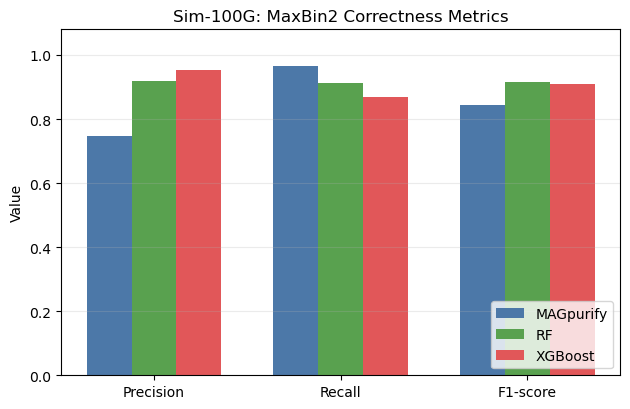

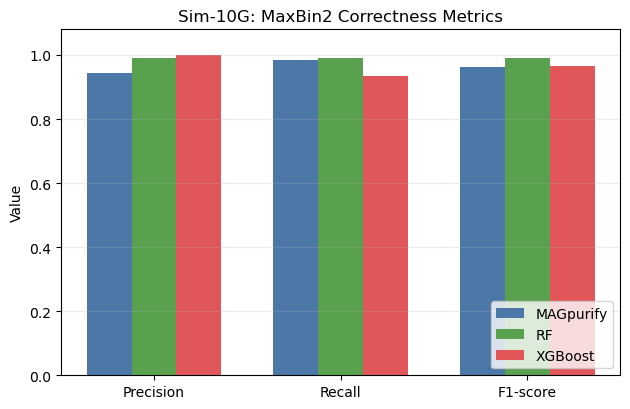

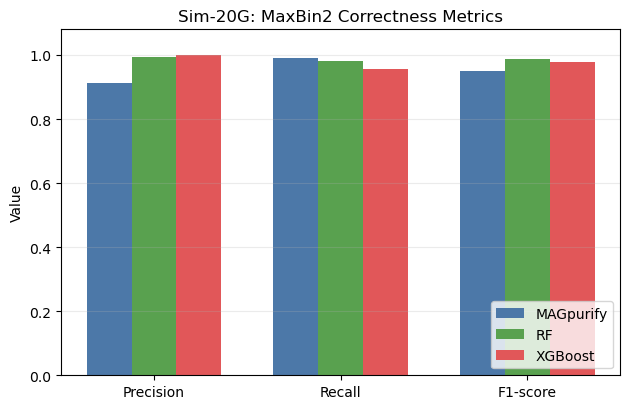

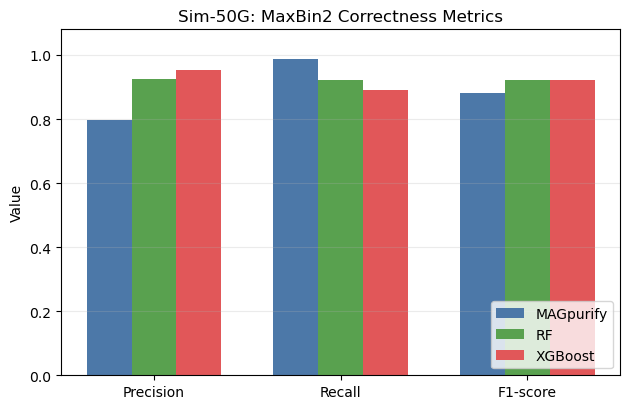

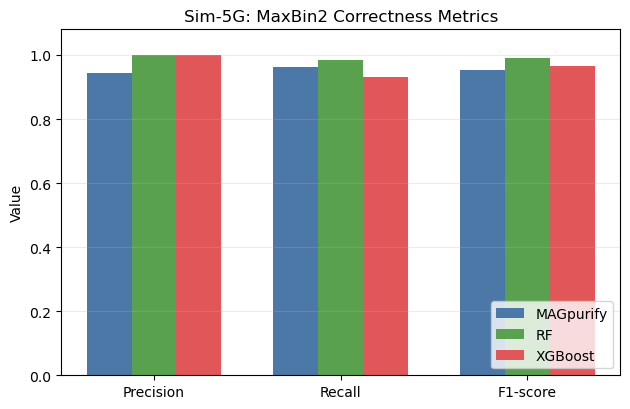

,dataset,image
0,Sim-100G,images/maxbin2_method_metrics_sim_100g.pdf
1,Sim-10G,images/maxbin2_method_metrics_sim_10g.pdf
2,Sim-20G,images/maxbin2_method_metrics_sim_20g.pdf
3,Sim-50G,images/maxbin2_method_metrics_sim_50g.pdf
4,Sim-5G,images/maxbin2_method_metrics_sim_5g.pdf


In [10]:
metric_order = ["precision", "recall", "f1_score"]
metric_labels = ["Precision", "Recall", "F1-score"]
method_order = ["MAGpurify", "RF", "XGBoost"]
colors = {"MAGpurify": "#4c78a8", "RF": "#59a14f", "XGBoost": "#e15759"}

plot_rows = []
for dataset in sorted(comparison_metrics["dataset"].unique()):
    dataset_metrics = comparison_metrics[comparison_metrics["dataset"].eq(dataset)]

    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    x_positions = range(len(metric_order))
    bar_width = 0.24

    for method_index, method in enumerate(method_order):
        method_values = dataset_metrics[dataset_metrics["method"].eq(method)]
        if method_values.empty:
            continue
        row = method_values.iloc[0]
        offsets = [x + (method_index - 1) * bar_width for x in x_positions]
        values = [row[metric] for metric in metric_order]
        ax.bar(offsets, values, width=bar_width, label=method, color=colors[method])

    ax.set_title(f"{dataset}: MaxBin2 Correctness Metrics")
    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(metric_labels)
    ax.set_ylabel("Value")
    ax.set_ylim(0, 1.08)
    ax.legend(loc="lower right")
    ax.grid(axis="y", alpha=0.25)

    if "MAGpurify" not in set(dataset_metrics["method"].astype(str)):
        ax.text(0.5, 0.04, "MAGpurify cleaned/ output unavailable", transform=ax.transAxes, ha="center")

    fig.tight_layout()
    image_path = IMAGES_DIR / f"maxbin2_method_metrics_{dataset.lower().replace('-', '_')}.pdf"
    fig.savefig(image_path, dpi=300, bbox_inches="tight")
    plot_rows.append({"dataset": dataset, "image": str(image_path.relative_to(PROJECT_ROOT))})
    plt.show()

display(pd.DataFrame(plot_rows))


## F1-score by Dataset

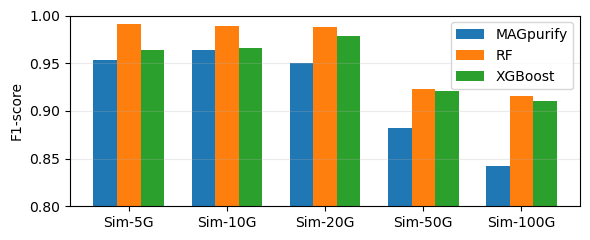

,image
0,images/maxbin2_method_f1_by_dataset.pdf


In [11]:
dataset_order = ["Sim-5G", "Sim-10G", "Sim-20G", "Sim-50G", "Sim-100G"]
fig, ax = plt.subplots(figsize=(6, 2.5))
x_positions = range(len(dataset_order))
bar_width = 0.24

for method_index, method in enumerate(method_order):
    method_metrics = comparison_metrics[comparison_metrics["method"].eq(method)].set_index("dataset")
    values = [method_metrics.loc[dataset, "f1_score"] if dataset in method_metrics.index else float("nan") for dataset in dataset_order]
    offsets = [x + (method_index - 1) * bar_width for x in x_positions]
    ax.bar(offsets, values, width=bar_width, label=method)

ax.set_xticks(list(x_positions))
ax.set_xticklabels(dataset_order)
ax.set_ylabel("F1-score")
ax.set_ylim(0.8, 1.0)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

f1_image_path = IMAGES_DIR / "maxbin2_method_f1_by_dataset.pdf"
fig.savefig(f1_image_path, dpi=300, bbox_inches="tight")
plt.show()

display(pd.DataFrame([{"image": str(f1_image_path.relative_to(PROJECT_ROOT))}]))


Datasets with `status == "missing cleaned/"` were not scored because there was no Magpurify output to compare against.